In [82]:
# Import all required libraries
import os
import pandas as pd
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


#### Cell 2: Organize Images into Class Folders

In [83]:
# Paths
BASE_DIR = r'E:\Hull Data Science\First Semester\CNN'
TRAIN_FLAT = os.path.join(BASE_DIR, 'train')      # Main CNN folder
TEST_FLAT = os.path.join(BASE_DIR, 'test')        # Flat folder with all training images + train.csv
CSV_PATH = os.path.join(TRAIN_FLAT, 'train.csv')  # Test images (no labels)


In [84]:
# Label mapping: 1-6 → class names
LABEL_MAP = {
    1: 'crack',
    2: 'scratch',
    3: 'tire_flat',
    4: 'dent',
    5: 'glass_shatter',
    6: 'lamp_broken'
}
CLASSES = list(LABEL_MAP.values())

# Load train.csv
df = pd.read_csv(CSV_PATH)

In [85]:
# Map numeric labels to class names
df['class_name'] = df['label'].map(LABEL_MAP)

print("Sample rows:")
print(df.head(10))
print("\nClass distribution:")
print(df['class_name'].value_counts())

Sample rows:
   image_id filename  label     class_name
0         1    1.jpg      2        scratch
1         2    2.jpg      4           dent
2         3    3.jpg      2        scratch
3         4    4.jpg      3      tire_flat
4         5    5.jpg      5  glass_shatter
5         6    6.jpg      2        scratch
6         7    7.jpg      5  glass_shatter
7         8    8.jpg      5  glass_shatter
8         9    9.jpg      5  glass_shatter
9        10   10.jpg      5  glass_shatter

Class distribution:
class_name
scratch          2349
dent             2079
glass_shatter    1185
lamp_broken       882
tire_flat         534
crack             171
Name: count, dtype: int64


In [86]:
# Split: 80% train, 20% validation
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label'] 
)

train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
print("Train split:", len(train_df))
print("Val split  :", len(val_df))

Train split: 5760
Val split  : 1440


In [87]:
# Count per class in original, train, and val
original_counts = df['class_name'].value_counts().sort_index()
train_counts = train_df['class_name'].value_counts().sort_index()
val_counts = val_df['class_name'].value_counts().sort_index()

# Create a nice DataFrame to display
split_summary = pd.DataFrame({
    'Label': original_counts.index,
    'Total': original_counts.values,
    'Train (80%)': train_counts.values,
    'Val (20%)': val_counts.values
})

In [88]:
# Add percentage check (should be very close to 80/20)
split_summary['Train %'] = (split_summary['Train (80%)'] / split_summary['Total'] * 100).round(2)
split_summary['Val %'] = (split_summary['Val (20%)'] / split_summary['Total'] * 100).round(2)

# Reorder columns for clean output
split_summary = split_summary[['Label', 'Total', 'Train (80%)', 'Train %', 'Val (20%)', 'Val %']]

print("Stratified Train/Validation Split Distribution (6 Classes)")
print("="*70)
print(split_summary.to_string(index=False))

# Total check
print("\nTotal images:")
print(f"Original: {len(df)} | Train: {len(train_df)} | Validation: {len(val_df)}")
print(f"Train ratio: {len(train_df)/len(df)*100:.2f}% | Val ratio: {len(val_df)/len(df)*100:.2f}%")

Stratified Train/Validation Split Distribution (6 Classes)
        Label  Total  Train (80%)  Train %  Val (20%)  Val %
        crack    171          137    80.12         34  19.88
         dent   2079         1663    79.99        416  20.01
glass_shatter   1185          948    80.00        237  20.00
  lamp_broken    882          706    80.05        176  19.95
      scratch   2349         1879    79.99        470  20.01
    tire_flat    534          427    79.96        107  20.04

Total images:
Original: 7200 | Train: 5760 | Validation: 1440
Train ratio: 80.00% | Val ratio: 20.00%


#### Cell 3: Data Generators

In [89]:
IMG_SIZE = (224, 224)  # Optimal for MobileNetV2
BATCH_SIZE = 32
# Data augmentation for training set (helps improve generalization and prevent overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0, 1] range
    rotation_range=15,           # Randomly rotate images by up to 15 degrees
    shear_range=0.1,             # Apply random shear transformations
    zoom_range=0.15,             # Randomly zoom in/out by up to 15%
    horizontal_flip=True,        # Randomly flip images horizontally (useful for symmetric defects)
    fill_mode='nearest'          # Fill any empty pixels created by transformations using nearest neighbor
)

# Validation/test data generator - only rescaling (no augmentation to keep evaluation realistic)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create training data generator from dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,          # DataFrame containing filenames and labels (training split)
    directory=TRAIN_FLAT,        # Root directory where all images are stored (flat structure)
    x_col='filename',            # Column name in DataFrame that contains image filenames
    y_col='label',               # Column name in DataFrame that contains labels (as strings)
    target_size=IMG_SIZE,        # Resize all images to IMG_SIZE (e.g., (192, 192))
    batch_size=BATCH_SIZE,       # Number of images per batch
    class_mode='categorical',    # One-hot encoded labels for multi-class classification
    shuffle=True,                # Shuffle batches each epoch for better training
    seed=42                      # Set seed for reproducibility
)

# Create validation data generator from dataframe
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,            # DataFrame containing filenames and labels (validation split)
    directory=TRAIN_FLAT,        # Same flat directory containing all images
    x_col='filename',            # Column with image filenames
    y_col='label',               # Column with labels (must be string type)
    target_size=IMG_SIZE,        # Resize images to same size as training
    batch_size=BATCH_SIZE,       # Same batch size as training for consistency
    class_mode='categorical',    # One-hot encoding for labels
    shuffle=False                # Do not shuffle validation data (important for consistent metrics)
)

# Print the mapping of class names (as strings) to their integer indices
# This is useful to understand how Keras internally encodes your 6 classes
print("\nClass indices:")
print(train_generator.class_indices)

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.

Class indices:
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5}


#### Cell 4: Build CNN Model

In [90]:
# CNN architecture with 3 convolutional blocks
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),
    BatchNormalization(),
    
    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),                           # Regularization to reduce overfitting
    Dense(6, activation='softmax')          # 6 classes
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()                      # Shows model architecture and parameters

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 111, 111, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 54, 54, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 26, 26, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,247,110 (84.87 MB)

 Trainable params: 22,246,662 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

#### Cell 5: Callbacks

In [91]:
# List of callbacks to control training behavior and save the best model
callbacks = [
    # Saves the best model (based on validation accuracy) during training
    # Uses the modern .keras format which stores the full model: architecture + weights + optimizer state
    ModelCheckpoint(
        filepath='best_damage_model.keras',   # File path where the best model will be saved
        monitor='val_accuracy',               # Metric to monitor for improvement
        save_best_only=True,                  # Only overwrite if the monitored metric improves
        save_weights_only=False,              # Save the entire model (not just weights) – recommended for .keras
        verbose=1                             # Print a message each time the model is saved
    ),
    
    # Stops training early if the model stops improving, preventing overfitting
    EarlyStopping(
        monitor='val_accuracy',               # Stop when validation accuracy no longer improves
        patience=12,                          # Wait 12 epochs after the last improvement before stopping
        restore_best_weights=True,            # Roll back to the weights of the best epoch when stopping
        verbose=1                             # Print message when early stopping is triggered
    ),
    
    # Dynamically reduces the learning rate when improvement stalls (helps fine-tune convergence)
    ReduceLROnPlateau(
        monitor='val_accuracy',               # Reduce LR when validation accuracy plateaus
        factor=0.5,                           # Multiply learning rate by 0.5 each time it's triggered
        patience=5,                           # Wait 5 epochs without improvement before reducing LR
        min_lr=1e-7,                          # Lower bound – learning rate won't go below this value
        verbose=1                             # Print message each time the learning rate is reduced
    )
]

#### Cell 6: Train Model

In [92]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=80,                     
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3662 - loss: 20.5680
Epoch 1: val_accuracy improved from None to 0.34167, saving model to best_damage_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.3747 - loss: 17.0620 - val_accuracy: 0.3417 - val_loss: 15.7106 - learning_rate: 0.0010
Epoch 2/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4366 - loss: 6.2461
Epoch 2: val_accuracy improved from 0.34167 to 0.43403, saving model to best_damage_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.4339 - loss: 4.6050 - val_accuracy: 0.4340 - val_loss: 3.1966 - learning_rate: 0.0010
Epoch 3/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4626 - loss: 1.8805
Epoch 3: val_accuracy improved from 0.43403 to 0.49236, saving model to best_damage_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.4540 - loss: 1.7266 - val_accuracy: 0.4924 - val_loss: 1.1865 - learning_rate: 0.0010
Epoch 4/80
180/180 ━━━━━━━━━━━━

#### Cell 7: Evaluate & Visualize

In [93]:
print("Loading the best saved model...")

# Load the entire saved model from the .keras file
# This loads the full model: architecture + trained weights + optimizer state
model = load_model('best_damage_model.keras')

# Evaluate the loaded best model on the validation set
val_loss, val_acc = model.evaluate(val_generator, verbose=1)

print(f"\n=== Best Model Performance ===")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f} ({val_acc * 100:.2f}%)")

Loading the best saved model...
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 316ms/step - accuracy: 0.9521 - loss: 0.1503

=== Best Model Performance ===
Validation Loss     : 0.1503
Validation Accuracy : 0.9521 (95.21%)


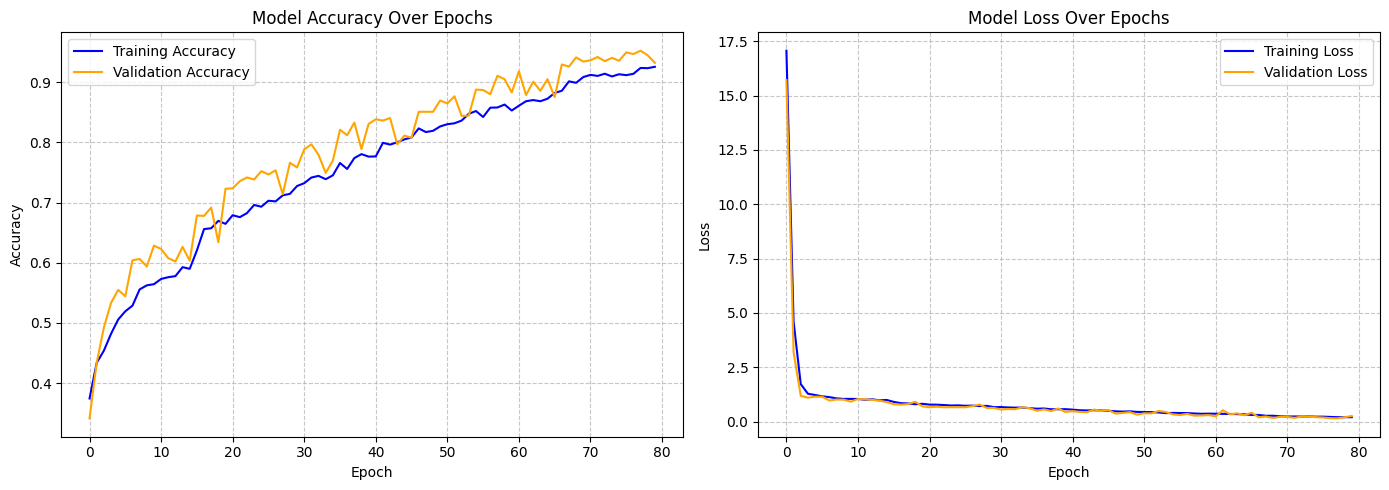

Generating predictions on validation set...
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 319ms/step

Classification Report:
               precision    recall  f1-score   support

        crack       1.00      0.65      0.79        34
      scratch       0.91      0.96      0.94       470
    tire_flat       0.99      0.99      0.99       107
         dent       0.95      0.93      0.94       416
glass_shatter       0.99      0.99      0.99       237
  lamp_broken       0.97      0.97      0.97       176

     accuracy                           0.95      1440
    macro avg       0.97      0.91      0.94      1440
 weighted avg       0.95      0.95      0.95      1440



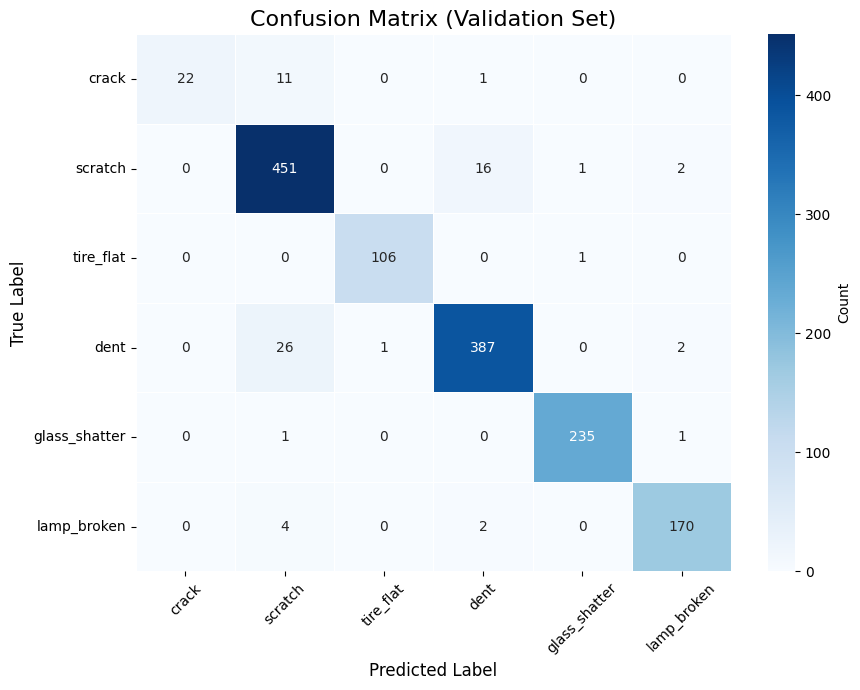


Final Best Model Performance:
Validation Loss     : 0.1503
Validation Accuracy : 0.9521 (95.21%)


In [94]:
# Training History Plots (Accuracy & Loss)
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#  Classification Report on Validation Set
print("Generating predictions on validation set...")

# Get model predictions (probabilities → class indices)
Y_pred_prob = model.predict(val_generator, verbose=1)
Y_pred = np.argmax(Y_pred_prob, axis=1)

# True labels from the generator
Y_true = val_generator.classes

# Class names (from your LABEL_MAP)
# CLASSES = ['crack', 'scratch', 'tire_flat', 'dent', 'glass_shatter', 'lamp_broken']
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred, target_names=CLASSES))
# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=CLASSES, 
            yticklabels=CLASSES,
            cbar_kws={'label': 'Count'},
            linewidths=0.5)

plt.title('Confusion Matrix (Validation Set)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"\nFinal Best Model Performance:")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f} ({val_acc * 100:.2f}%)")

#### Cell 8: Predict on Test Set Submission

In [98]:
# Load the original test.csv (with image_id and filename)
df_test = pd.read_csv(r"E:\Hull Data Science\First Semester\CNN\test\test.csv")  # Path to your test.csv
print(f"Loaded test.csv with {len(df_test)} images")

# Create test generator to load images from the 'test' folder in correct order
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    BASE_DIR,                    # Parent folder containing 'test'
    classes=['test'],            # Load only from 'test' subfolder
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode=None,             # No labels
    shuffle=False                # VERY IMPORTANT: keeps order matching test.csv
)

# Predict labels
print("Predicting labels for test images...")
predictions = model.predict(test_generator, verbose=1)
pred_labels = np.argmax(predictions, axis=1) + 1  # Convert 0-5 → 1-6

# Add the predicted label column to the original test.csv dataframe
df_test['label'] = pred_labels

# Optional: Add class name for better readability
class_names = ['crack', 'scratch', 'tire_flat', 'dent', 'glass_shatter', 'lamp_broken']
df_test['class_name'] = df_test['label'].map(dict(enumerate(class_names, 1)))

# Save the updated CSV with the new 'label' column
updated_csv_path = os.path.join(BASE_DIR, 'test_with_predicted_labels.csv')
df_test.to_csv(updated_csv_path, index=False)

print(f"\nUpdated test.csv saved with labels: {updated_csv_path}")
print("Columns: image_id, filename, label, class_name")

Loaded test.csv with 4800 images
Found 4800 images belonging to 1 classes.
Predicting labels for test images...
150/150 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step

Updated test.csv saved with labels: E:\Hull Data Science\First Semester\CNN\test_with_predicted_labels.csv
Columns: image_id, filename, label, class_name
